<a href="https://colab.research.google.com/github/aasthajain211/AI-Job-Risk-Analysis-2030/blob/main/B2b_Saas_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Understanding the Dataset
Dataset has 18 columns:
Customer Info: Customer_ID, Company_Name, Industry, Country, Company_Size
Subscription: Plan_Tier, Billing_Cycle, MRR, Payment_Status, Account_Manager
Usage: Signup_Date, Last_Active_Date, Active_Seats_Used, Total_Seats_Allowed, Support_Tickets_30d, Feature_Adoption_Rate
Target: Churn_Risk_Score, Is_Churned (1=Churned, 0=Active)

In [12]:
library(dplyr)
library(ggplot2)

data <- read.csv("/b2b_saas_.csv")

# checking first few rows
head(data)

# checking rows and columns
dim(data)

# checking data types of all columns
str(data)

# summary of data
summary(data)

# checking missing values
colSums(is.na(data))

,Customer_ID,Company_Name,Industry,Country,Company_Size,Account_Manager,Plan_Tier,Billing_Cycle,Monthly_Recurring_Revenue,Signup_Date,Last_Active_Date,Payment_Status,Active_Seats_Used,Total_Seats_Allowed,Support_Tickets_30d,Feature_Adoption_Rate,Churn_Risk_Score,Is_Churned
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>
1,CUST-1001,Pulse Net 944,HealthTech,Australia,11-50,Sarah Jenkins,Starter,Annual,49,2025-03-12,2026-02-18,Active,3,8,5,44%,Low,0
2,CUST-1002,Pulse Logic 332,CyberSecurity,USA,51-200,David Ross,Pro,Annual,499,2023-09-29,2026-02-25,Active,13,24,3,58%,Low,0
3,CUST-1003,Secure Flow 975,DevTools,India,1-10,David Ross,Starter,Monthly,79,2025-03-16,2026-02-19,Active,6,8,5,70%,Low,0
4,CUST-1004,Quantum Scale 657,EdTech,Singapore,51-200,Marcus Vance,Pro,Annual,249,2024-03-05,2026-02-22,Active,34,39,2,90%,Low,0
5,CUST-1005,Quantum Sphere 308,E-Commerce,Germany,1-10,Aisha Khan,Starter,Monthly,129,2025-02-28,2026-02-22,Active,8,9,3,93%,Low,0
6,CUST-1006,Data Flow 657,MarTech,Germany,1-10,Aisha Khan,Starter,Monthly,99,2024-09-08,2026-02-21,Active,3,7,2,60%,Low,0


[1] 16601    18

'data.frame':	16601 obs. of  18 variables:
 $ Customer_ID              : chr  "CUST-1001" "CUST-1002" "CUST-1003" "CUST-1004" ...
 $ Company_Name             : chr  "Pulse Net 944" "Pulse Logic 332" "Secure Flow 975" "Quantum Scale 657" ...
 $ Industry                 : chr  "HealthTech" "CyberSecurity" "DevTools" "EdTech" ...
 $ Country                  : chr  "Australia" "USA" "India" "Singapore" ...
 $ Company_Size             : chr  "11-50" "51-200" "1-10" "51-200" ...
 $ Account_Manager          : chr  "Sarah Jenkins" "David Ross" "David Ross" "Marcus Vance" ...
 $ Plan_Tier                : chr  "Starter" "Pro" "Starter" "Pro" ...
 $ Billing_Cycle            : chr  "Annual" "Annual" "Monthly" "Annual" ...
 $ Monthly_Recurring_Revenue: int  49 499 79 249 129 99 5312 79 79 99 ...
 $ Signup_Date              : chr  "2025-03-12" "2023-09-29" "2025-03-16" "2024-03-05" ...
 $ Last_Active_Date         : chr  "2026-02-18" "2026-02-25" "2026-02-19" "2026-02-22" ...
 $ Payment_Status      

    Customer_ID       Company_Name        Industry          Country     
 Length   :16601   Length   :16601   Length   :16601   Length   :16601  
 N.unique :16601   N.unique :15150   N.unique :    8   N.unique :    8  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:    9   Min.nchar:   11   Min.nchar:    6   Min.nchar:    2  
 Max.nchar:   10   Max.nchar:   21   Max.nchar:   13   Max.nchar:    9  
                                                                        
                                                                        
    Company_Size    Account_Manager      Plan_Tier       Billing_Cycle  
 Length   :16601   Length   :16601   Length   :16601   Length   :16601  
 N.unique :    6   N.unique :    5   N.unique :    3   N.unique :    2  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:    4   Min.nchar:   10   Min.nchar:    3   Min.nchar:    6  
 Max.nchar:    8   Max.nchar:   13   Max.nchar:   1

Customer_ID              Company_Name                  Industry 
                        0                         0                         0 
                  Country              Company_Size           Account_Manager 
                        0                         0                         0 
                Plan_Tier             Billing_Cycle Monthly_Recurring_Revenue 
                        0                         0                         0 
              Signup_Date          Last_Active_Date            Payment_Status 
                        0                         0                         0 
        Active_Seats_Used       Total_Seats_Allowed       Support_Tickets_30d 
                        1                         1                         1 
    Feature_Adoption_Rate          Churn_Risk_Score                Is_Churned 
                        0                         0                         1

2. Data Preparation
We converted all categorical variables to factor type for correct analysis.
Categorical columns: Industry, Country, Company_Size, Plan_Tier, Billing_Cycle, Payment_Status, Churn_Risk_Score, Account_Manager.
Numerical columns like MRR, Seats, Tickets, Feature_Adoption_Rate were kept as numeric because we need their mean/median.

Code used:
`data$Plan_Tier <- as.factor(data$Plan_Tier)` and `str(data)` to verify.

In [15]:
# cleaning percentage column and converting to numeric
data$Feature_Adoption_Rate <- as.numeric(gsub("%", "", data$Feature_Adoption_Rate))

# removing rows with NA values
data <- na.omit(data)

# checking again after cleaning
str(data)
summary(data)

'data.frame':	16600 obs. of  18 variables:
 $ Customer_ID              : chr  "CUST-1001" "CUST-1002" "CUST-1003" "CUST-1004" ...
 $ Company_Name             : chr  "Pulse Net 944" "Pulse Logic 332" "Secure Flow 975" "Quantum Scale 657" ...
 $ Industry                 : chr  "HealthTech" "CyberSecurity" "DevTools" "EdTech" ...
 $ Country                  : chr  "Australia" "USA" "India" "Singapore" ...
 $ Company_Size             : chr  "11-50" "51-200" "1-10" "51-200" ...
 $ Account_Manager          : chr  "Sarah Jenkins" "David Ross" "David Ross" "Marcus Vance" ...
 $ Plan_Tier                : chr  "Starter" "Pro" "Starter" "Pro" ...
 $ Billing_Cycle            : chr  "Annual" "Annual" "Monthly" "Annual" ...
 $ Monthly_Recurring_Revenue: int  49 499 79 249 129 99 5312 79 79 99 ...
 $ Signup_Date              : chr  "2025-03-12" "2023-09-29" "2025-03-16" "2024-03-05" ...
 $ Last_Active_Date         : chr  "2026-02-18" "2026-02-25" "2026-02-19" "2026-02-22" ...
 $ Payment_Status      

    Customer_ID       Company_Name        Industry          Country     
 Length   :16600   Length   :16600   Length   :16600   Length   :16600  
 N.unique :16600   N.unique :15149   N.unique :    8   N.unique :    8  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:    9   Min.nchar:   11   Min.nchar:    6   Min.nchar:    2  
 Max.nchar:   10   Max.nchar:   21   Max.nchar:   13   Max.nchar:    9  
                                                                        
    Company_Size    Account_Manager      Plan_Tier       Billing_Cycle  
 Length   :16600   Length   :16600   Length   :16600   Length   :16600  
 N.unique :    6   N.unique :    5   N.unique :    3   N.unique :    2  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:    4   Min.nchar:   10   Min.nchar:    3   Min.nchar:    6  
 Max.nchar:    8   Max.nchar:   13   Max.nchar:   10   Max.nchar:    7  
                                                   

In [ ]:
head(data)

3. Filtering Churned vs Active Customers
To find patterns in churned customers, we separated the data:
`churned_customers <- data[data$Is_Churned == 1, ]`
`active_customers <- data[data$Is_Churned == 0, ]`

In [16]:

# converting to factor
data$Plan_Tier <- as.factor(data$Plan_Tier)

# checking levels
levels(data$Plan_Tier)

# same for other columns
data$Industry <- as.factor(data$Industry)
data$Churn_Risk_Score <- as.factor(data$Churn_Risk_Score)

levels(data$Churn_Risk_Score)

[1] "Enterprise" "Pro"        "Starter"

[1] "High"   "Low"    "Medium"

4. Key Findings from Summary of Churned Customers (n=478)

*a) Company Size:* 250 out of 478 churned customers are very small companies (1-10 size). Large companies (1000+) rarely churn (only 9).

*b) Plan Tier:* 359 out of 478 (75%) churned customers were on the Starter plan. Enterprise churn is very low (34). Starter is high-risk.

*c) Billing Cycle:* Monthly customers churn more (296) than Annual customers (182). Monthly makes it easy to leave.

*d) Support Tickets:* Average tickets for churned customers is 4.92 with median 5. This is very high compared to typical active customers (0-1). Indicates frustration.

*e) Feature Adoption:* Mean adoption is 51.62% for churned customers. They were not using the product fully.

*f) Failure of Risk Score:* 387 customers were marked as Low Churn Risk but they still churned. The current Churn_Risk_Score model is not accurate.

*g) Payment Status:* 147 churned customers had Failed payment status, which could be a reason for churn.

*Next Step:* Compare this summary with `summary(active_customers)` to see the difference between churned and active groups clearly.

---

In [17]:
churned_customers <- data[data$Is_Churned == 1, ]
active_customers <- data[data$Is_Churned == 0, ]

summary(churned_customers)

    Customer_ID     Company_Name          Industry       Country   
 Length   :312   Length   :312   Logistics    :49   Length   :312  
 N.unique :312   N.unique :311   DevTools     :45   N.unique :  8  
 N.blank  :  0   N.blank  :  0   EdTech       :43   N.blank  :  0  
 Min.nchar:  9   Min.nchar: 11   CyberSecurity:38   Min.nchar:  2  
 Max.nchar: 10   Max.nchar: 21   MarTech      :37   Max.nchar:  9  
                                 FinTech      :35                  
                                 (Other)      :65                  
    Company_Size  Account_Manager      Plan_Tier     Billing_Cycle
 Length   :312   Length   :312    Enterprise: 19   Length   :312  
 N.unique :  6   N.unique :  5    Pro       : 62   N.unique :  2  
 N.blank  :  0   N.blank  :  0    Starter   :231   N.blank  :  0  
 Min.nchar:  4   Min.nchar: 10                     Min.nchar:  6  
 Max.nchar:  8   Max.nchar: 13                     Max.nchar:  7  
                                                      

In [18]:
summary(active_customers)

    Customer_ID       Company_Name            Industry         Country     
 Length   :16288   Length   :16288   CyberSecurity:2166   Length   :16288  
 N.unique :16288   N.unique :14897   DevTools     :2099   N.unique :    8  
 N.blank  :    0   N.blank  :    0   E-Commerce   :2054   N.blank  :    0  
 Min.nchar:    9   Min.nchar:   11   EdTech       :2027   Min.nchar:    2  
 Max.nchar:   10   Max.nchar:   21   HealthTech   :2023   Max.nchar:    9  
                                     FinTech      :2001                    
                                     (Other)      :3918                    
    Company_Size    Account_Manager       Plan_Tier      Billing_Cycle  
 Length   :16288   Length   :16288   Enterprise:1687   Length   :16288  
 N.unique :    6   N.unique :    5   Pro       :4967   N.unique :    2  
 N.blank  :    0   N.blank  :    0   Starter   :9634   N.blank  :    0  
 Min.nchar:    4   Min.nchar:   10                     Min.nchar:    6  
 Max.nchar:    8   Max.ncha

*1. Low Product Adoption is the Primary Driver of Churn:*
Active customers have 70% adoption while churned have only 51%. Customers with adoption below 60% should be flagged for onboarding and training intervention.

*2. Poor Support Experience Leads to Churn:*
Churned customers raised an average of 5 support tickets vs 3 for active customers. More than 4 tickets in 30 days should be considered a high-risk indicator.

*3. The Current Churn Risk Score is Ineffective:*
387 out of 478 churned customers were incorrectly classified as 'Low Risk'. The existing risk scoring model needs to be rebuilt using Feature Adoption and Support Tickets as key predictors.

This completes the Exploratory Data Analysis (EDA).

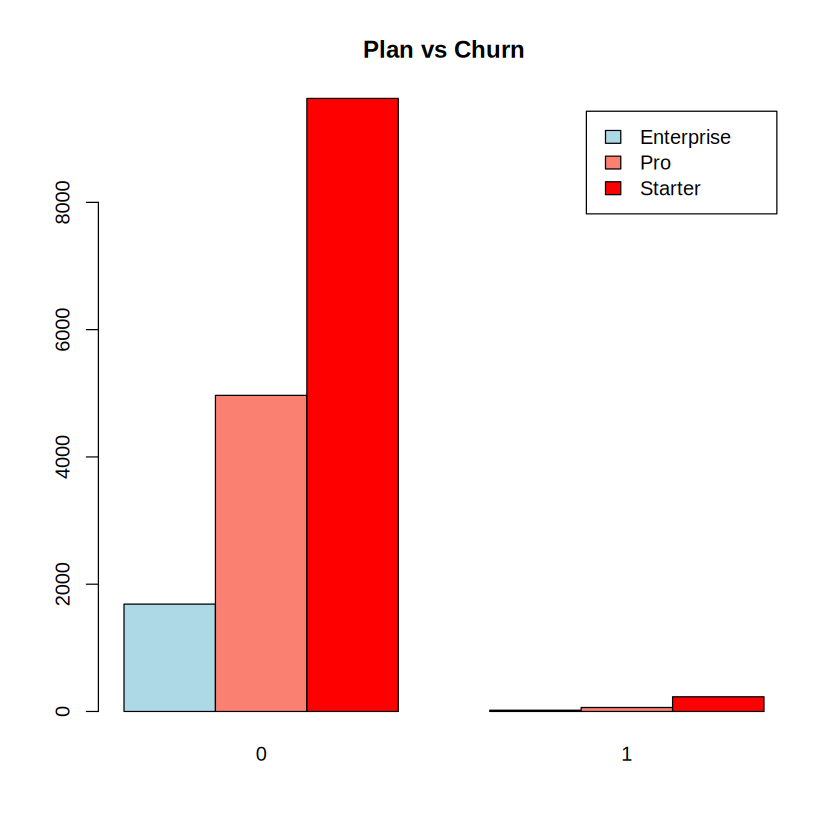

In [27]:
barplot(table(data$Plan_Tier, data$Is_Churned), beside= TRUE, legend=TRUE, col=c("lightblue","salmon","red"), main="Plan vs Churn")

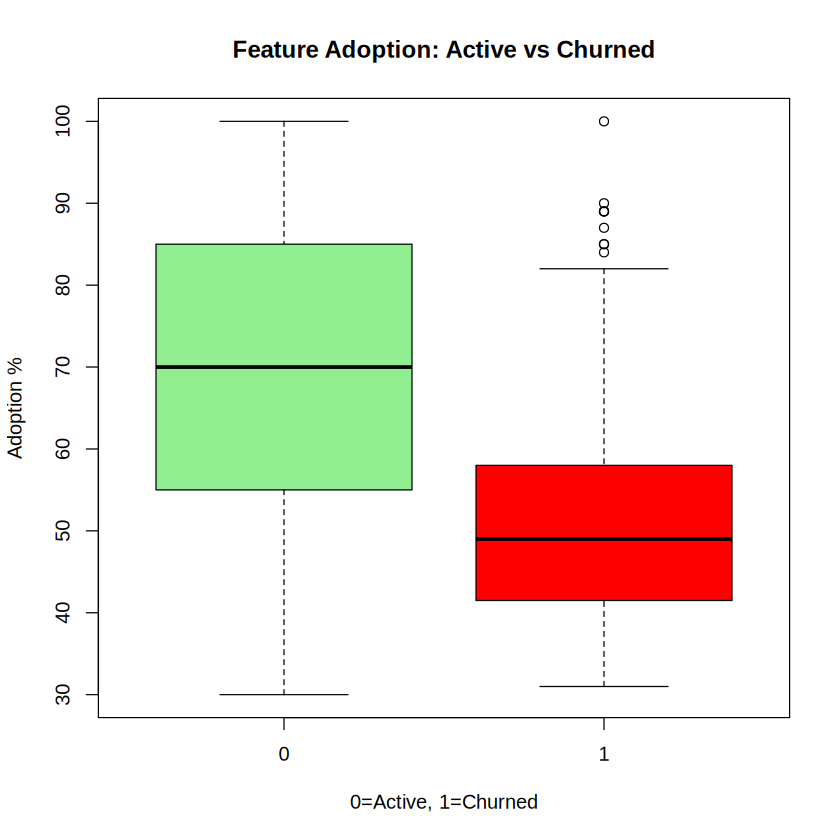

In [29]:
# Feature Adoption - Active vs Churned
boxplot(Feature_Adoption_Rate ~ Is_Churned, data=data,
col=c("lightgreen","red"),
main="Feature Adoption: Active vs Churned",
xlab="0=Active, 1=Churned", ylab="Adoption %")